# 02 - MIMIC-IV-ECG exploratory data analysis

MIMIC-IV-ECG contains about 800,000 diagnostic ECGs from roughly 160,000 patients at the Beth Israel
Deaconess Medical Center (Boston), recorded in hospital and emergency settings. The release has no
cardiologist labels, but each ECG comes with the cart's automatic report text and interval
measurements. This notebook describes that data: its structure, missing and impossible values, what
the machine reports say and whether they are internally consistent, and what the waveforms look like.

Metadata comes from the official `record_list.csv` and `machine_measurements.csv` (all 800,035
studies). Waveforms come from the 200,000 records stored locally (whole patients, chosen at random).

**Data use.** MIMIC is credentialed data. This notebook only shows aggregate statistics, never individual
records, identifiers or waveforms. The waveform release has no age or sex; those live in the separate
MIMIC-IV clinical module, which is not part of this analysis.

In [1]:
import sys
from pathlib import Path

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from eda.cross import MIMIC_PATTERNS
from eda.mimic import (
    load_machine_measurements,
    load_records,
    measured_intervals,
    mimic_summary,
    nan_profile,
    read_signal_by_position,
    stored_lead_orders,
)
from eda.ptbxl import load_metadata
from eda.ptbxl_signals import ptbxl_summary
from eda.signals import LEADS, problem_counts, signal_features

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
plt.rcParams.update({"figure.dpi": 100})

records = load_records()
measurements = load_machine_measurements()

## 1. Patients, studies and time

How many ECGs per patient, over what period, and is the local waveform subset representative?

,value
studies,800035.0
patients,161352.0
patients with one ECG,57344.0
median ECGs per patient,2.0
most ECGs for one patient,260.0
median days between first and last ECG (repeat patients),420.0
first year (shifted),2097.0
last year (shifted),2211.0
studies sharing patient and timestamp,2094.0


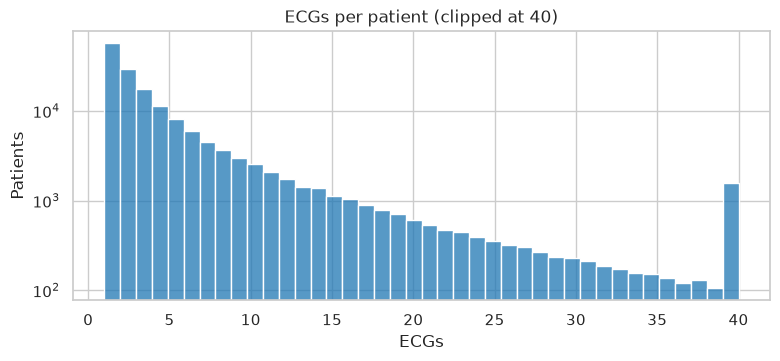

In [3]:
local = records[records["downloaded"]]
per_patient = records.groupby("subject_id").size()
span_days = records.groupby("subject_id")["ecg_time"].agg(lambda times: (times.max() - times.min()).days)
display(pd.Series({
    "studies": len(records),
    "patients": records["subject_id"].nunique(),
    "patients with one ECG": int((per_patient == 1).sum()),
    "median ECGs per patient": per_patient.median(),
    "most ECGs for one patient": int(per_patient.max()),
    "median days between first and last ECG (repeat patients)": span_days[per_patient > 1].median(),
    "first year (shifted)": records["ecg_time"].dt.year.min(),
    "last year (shifted)": records["ecg_time"].dt.year.max(),
    "studies sharing patient and timestamp": int(records.duplicated(["subject_id", "ecg_time"]).sum()),
}).to_frame("value"))
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.histplot(per_patient.clip(upper=40), bins=40, ax=ax, color="tab:blue")
ax.set(title="ECGs per patient (clipped at 40)", xlabel="ECGs", ylabel="Patients", yscale="log")
plt.show()

In [4]:
joined = records.join(measurements[["overall", "filtering"]])
selected = local["subject_id"].unique()
per_patient_frame = per_patient.rename("ecgs").to_frame()
per_patient_frame["local"] = per_patient_frame.index.isin(selected)
display(per_patient_frame.groupby("local")["ecgs"].describe().round(2)
        .rename(index={False: "not stored locally", True: "stored locally"}))
display(pd.crosstab(joined["overall"], joined["downloaded"], normalize="columns").round(3)
        .rename(columns={False: "not stored locally", True: "stored locally"}))

,count,mean,std,min,25%,50%,75%,max
local,,,,,,,,
not stored locally,120656.0,4.97,8.13,1.0,1.0,2.0,5.0,260.0
stored locally,40696.0,4.91,7.91,1.0,1.0,2.0,5.0,217.0


downloaded,not stored locally,stored locally
overall,,
Abnormal ECG,0.445,0.442
Borderline ECG,0.214,0.215
Normal ECG,0.193,0.196
no statement,0.147,0.146


**Finding: many repeat recordings, and a representative local subset.** About two thirds of the 161,352
patients (64%) have two or more ECGs, and a few have over 200. Among patients with repeat ECGs, the median span between
the first and the last is over a year. Dates are shifted into the 2100s by MIMIC's de-identification,
so only differences between dates are meaningful. 2,094 studies share both patient and timestamp with
another study, probably repeated acquisitions within the same minute. The locally stored 200,000
records come from 40,696 whole patients and match the rest of the release on ECGs per patient and on
the mix of machine interpretations.

## 2. Machine measurements: missing and impossible values

`machine_measurements.csv` holds the cart's report lines and interval measurements (ms) and axes
(degrees). They are automatic outputs, not cardiologist readings.

In [5]:
intervals = measured_intervals(measurements)
raw_columns = ["rr_interval", "p_onset", "p_end", "qrs_onset", "qrs_end", "t_end",
               "p_axis", "qrs_axis", "t_axis"]
display(pd.DataFrame({"NaN in the file": measurements[raw_columns].isna().mean(),
                      "exactly 29999": (measurements[raw_columns] == 29999).mean(),
                      "missing after cleaning": intervals[raw_columns].isna().mean()}).round(3))
impossible = pd.Series({
    "QRS duration <= 0 ms": int((intervals["qrs_duration"] <= 0).sum()),
    "QRS duration > 300 ms": int((intervals["qrs_duration"] > 300).sum()),
    "PR interval <= 0 ms": int((intervals["pr_interval"] <= 0).sum()),
    "RR interval of 0 ms (in the file)": int((measurements["rr_interval"] == 0).sum()),
    "heart rate > 250 bpm": int((intervals["heart_rate"] > 250).sum()),
})
display(impossible.to_frame("studies"))

,NaN in the file,exactly 29999,missing after cleaning
rr_interval,0.0,0.002,0.002
p_onset,0.0,0.154,0.154
p_end,0.0,0.288,0.288
qrs_onset,0.0,0.001,0.001
qrs_end,0.0,0.002,0.002
t_end,0.0,0.002,0.002
p_axis,0.0,0.154,0.164
qrs_axis,0.0,0.003,0.004
t_axis,0.0,0.003,0.006


,studies
QRS duration <= 0 ms,149
QRS duration > 300 ms,77
PR interval <= 0 ms,1
RR interval of 0 ms (in the file),188
heart rate > 250 bpm,3


**Finding: no NaNs, but a hidden missing-value code and a few impossible rows.** Every column is
filled in, yet 29999 means "not measured": 29% of P-wave ends and 15% of P-wave onsets carry it. That
is expected, since P waves are absent in atrial fibrillation and hard to detect in noisy recordings. A
few other impossible values also occur: 188 RR intervals of 0, timings just above 29000 ms, and axes of
-32768. `eda.mimic.measured_intervals` masks all of these. After masking, a small number of derived
durations are still impossible (for example 149 negative QRS durations), meaning an onset recorded after
its end. These rows should be dropped before using the intervals.

,count,mean,std,min,1%,50%,99%,max
heart_rate,798506.0,78.0,20.0,11.0,45.0,74.0,142.0,255.0
qrs_duration,798695.0,100.0,123.0,-7616.0,68.0,94.0,174.0,27584.0
pr_interval,676552.0,163.0,40.0,-40.0,92.0,160.0,269.0,7544.0
qtc,798485.0,445.0,33.0,195.0,376.0,442.0,516.0,932.0


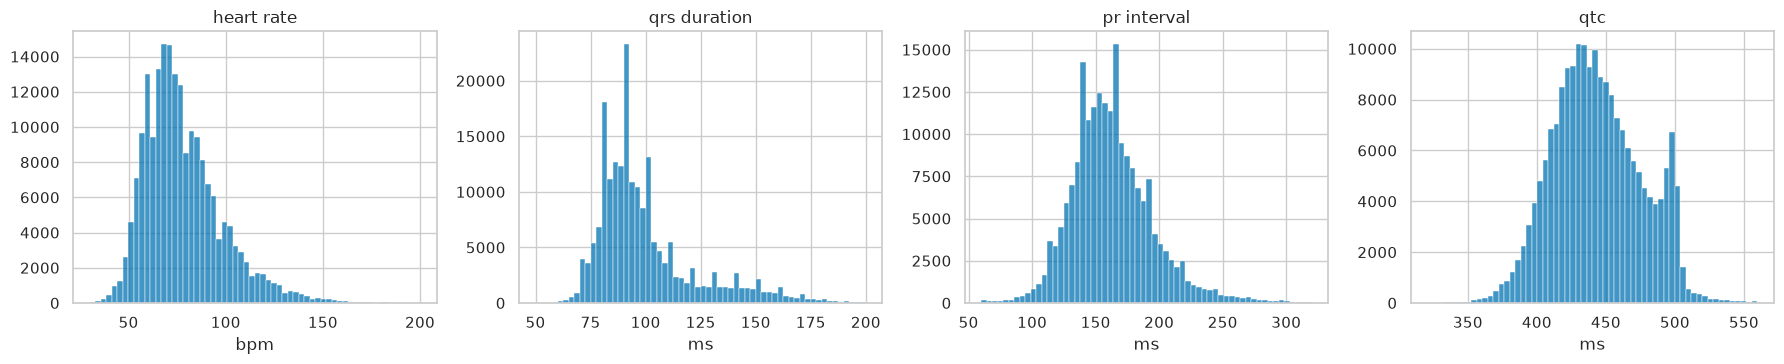

In [6]:
derived = intervals[["heart_rate", "qrs_duration", "pr_interval", "qtc"]]
display(derived.describe(percentiles=[0.01, 0.5, 0.99]).T.round(0))
limits = {"heart_rate": (30, 200), "qrs_duration": (50, 200), "pr_interval": (60, 320), "qtc": (320, 560)}
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for axis, (column, (low, high)) in zip(axes, limits.items(), strict=True):
    values = derived[column]
    sns.histplot(values[(values >= low) & (values <= high)].sample(200000, random_state=0), bins=60, ax=axis)
    axis.set(title=column.replace("_", " "), xlabel="bpm" if column == "heart_rate" else "ms", ylabel="")
plt.tight_layout()
plt.show()

**Finding.** Once cleaned, the intervals sit in their physiological ranges: median heart rate 74 bpm,
QRS duration 94 ms, PR interval 160 ms and QTc 442 ms. The QRS distribution has a long shoulder from
120 to 160 ms, which is where bundle branch blocks and paced rhythms sit (checked in the next section).
The spiky bars are measurement resolution: the cart reports intervals in steps of a few milliseconds.

The QTc histogram, however, has an odd shape: values pile up just below 500 ms and then fall off a
cliff. We look at it by device.

In [7]:
device = np.where(measurements["cart_id"] == 6632385, "the cart without interpretation", "all carts but one")
qtc = intervals["qtc"]
bands = pd.DataFrame({"QTc 495-505 ms": (qtc > 495) & (qtc < 505), "QTc above 505 ms": qtc > 505})
display(bands.groupby(device).mean().round(4))

,QTc 495-505 ms,QTc above 505 ms
all carts but one,0.072,0.008
the cart without interpretation,0.034,0.094


**Finding: long QT is truncated on the main cart system.** On all carts except one, 7.2% of QTc values
fall between 495 and 505 ms, but fewer than 1% exceed 505 ms. The remaining cart (the one without
interpretations, see section 5) shows a normal tail, with 9.4% above 505 ms. The main system's algorithm
apparently limits its QT measurement so that QTc rarely goes beyond about 500 ms. Long-QT values from
these carts are therefore censored and should not be used to study QT prolongation.

## 3. What the machine reports say, and do they agree with the measurements?

We extract six common findings from the report text and compare the intervals of studies with and
without each one. If the reports and the measurements come from a coherent system, each finding should
shift the interval that defines it.

In [8]:
reports = measurements["report"].str.lower()
findings = pd.DataFrame({name: reports.str.contains(pattern, regex=True)
                         for name, pattern in MIMIC_PATTERNS.items()})
findings["paced rhythm"] = reports.str.contains("pace")
findings["overall: normal ECG"] = measurements["overall"].eq("Normal ECG")
display(findings.mean().sort_values(ascending=False).round(3).to_frame("share of studies"))
intervals["p_not_measured"] = intervals["p_onset"].isna()
columns = {"qrs_duration": "QRS ms", "pr_interval": "PR ms", "heart_rate": "heart rate",
           "p_not_measured": "P wave not measured"}
rows = []
for name in findings.columns:
    with_finding = intervals.loc[findings[name], list(columns)].median()
    without = intervals.loc[~findings[name], list(columns)].median()
    with_finding["p_not_measured"] = intervals.loc[findings[name], "p_not_measured"].mean()
    without["p_not_measured"] = intervals.loc[~findings[name], "p_not_measured"].mean()
    row = {"finding": name, "studies": int(findings[name].sum())}
    row |= {f"{label} (with / without)": f"{with_finding[column]:.2f} / {without[column]:.2f}"
            if column == "p_not_measured" else f"{with_finding[column]:.0f} / {without[column]:.0f}"
            for column, label in columns.items()}
    rows.append(row)
display(pd.DataFrame(rows).set_index("finding"))

,share of studies
overall: normal ECG,0.194
sinus bradycardia,0.124
atrial fibrillation,0.101
sinus tachycardia,0.087
right bundle branch block,0.043
1st degree AV block,0.036
left bundle branch block,0.029
paced rhythm,0.025


,studies,QRS ms (with / without),PR ms (with / without),heart rate (with / without),P wave not measured (with / without)
finding,,,,,
atrial fibrillation,80768,98 / 92,146 / 160,85 / 73,0.90 / 0.07
right bundle branch block,34227,138 / 92,166 / 159,73 / 74,0.23 / 0.15
left bundle branch block,23567,144 / 92,176 / 158,74 / 74,0.22 / 0.15
1st degree AV block,29096,102 / 92,236 / 158,66 / 75,0.00 / 0.16
sinus bradycardia,99249,94 / 92,170 / 158,55 / 77,0.00 / 0.18
sinus tachycardia,69260,88 / 94,144 / 160,109 / 72,0.03 / 0.17
paced rhythm,19733,150 / 92,161 / 160,70 / 74,0.76 / 0.14
overall: normal ECG,155244,88 / 96,154 / 161,72 / 75,0.00 / 0.19


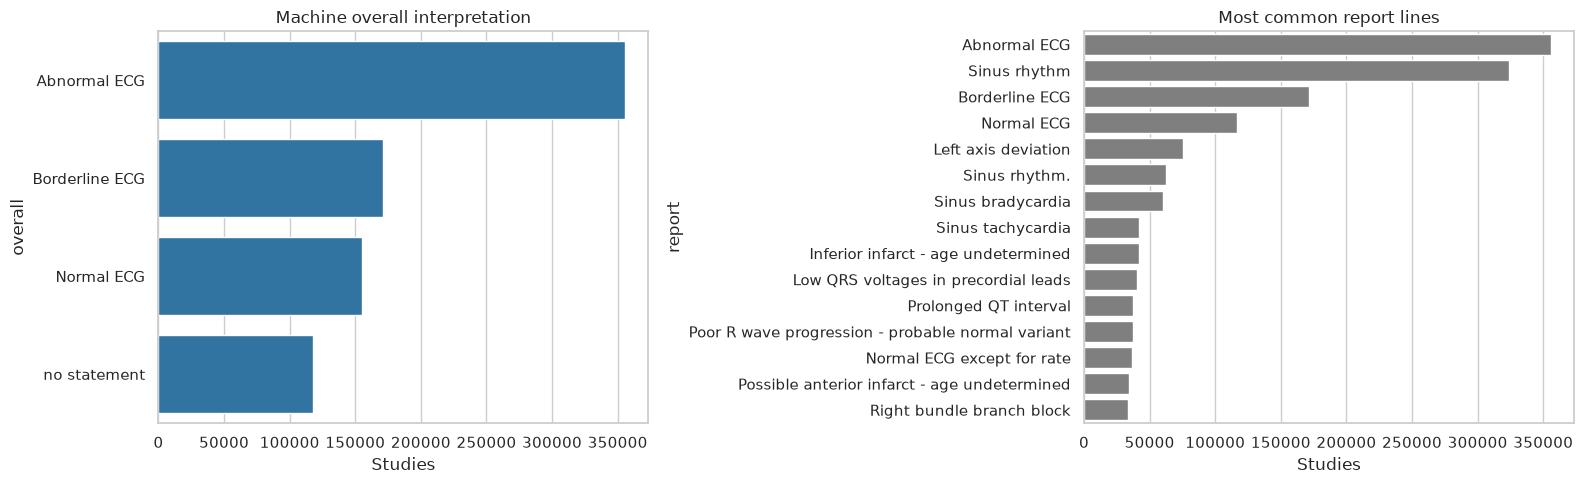

In [9]:
counts = measurements["overall"].value_counts()
lines = measurements["report"].str.split(" | ", regex=False).explode()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=counts.to_numpy(), y=counts.index, ax=axes[0], color="tab:blue")
axes[0].set(title="Machine overall interpretation", xlabel="Studies")
top = lines.value_counts().head(15)
sns.barplot(x=top.to_numpy(), y=top.index, ax=axes[1], color="tab:gray")
axes[1].set(title="Most common report lines", xlabel="Studies")
plt.tight_layout()
plt.show()

**Finding: the reports are internally consistent.** Each finding moves exactly the measurement that
defines it:

- **Bundle branch blocks** have a median QRS of about 138-144 ms against 92 ms otherwise, matching the
  definition (QRS of 120 ms or more). **Paced rhythms** are even wider (about 150 ms).
- **First-degree AV block** has a median PR of about 236 ms against 158 ms, matching the definition
  (PR over 200 ms).
- **Atrial fibrillation** has no measurable P wave in 90% of studies against 7% otherwise, and a faster
  rate.
- **Sinus bradycardia and tachycardia** have median rates of 55 and 109 bpm.

Atrial fibrillation appears in about 10% of studies, bundle branch blocks in 3-4%, and only 19% of
studies are called normal. This is a sick, hospital population. The machine labels are plausible proxy
labels, but they remain automatic interpretations.

## 4. Lead order

MIMIC headers store the leads as **I, II, III, aVR, aVF, aVL**, with aVF and aVL swapped relative to the
standard order. We check how consistent this is, and show what reading channels by position would do
to the limb-lead identities (aVL = (I - III)/2, aVF = (II + III)/2).

In [10]:
display(stored_lead_orders(records, sample=2000).to_frame("headers"))
rows = []
for path in local["path"].sample(200, random_state=0):
    signal, fs = read_signal_by_position(path)
    features = signal_features(signal, fs)
    rows.append({"aVL identity error (mV)": features["avl_residual"][0],
                 "aVF identity error (mV)": features["avf_residual"][0]})
positional = pd.DataFrame(rows)
summary = mimic_summary(records)
by_name = summary[["avl_residual", "avf_residual"]].median()
display(pd.DataFrame({"read by position": positional.median().to_numpy(),
                      "read by lead name": by_name.to_numpy()},
                     index=["aVL identity error (mV)", "aVF identity error (mV)"]).round(3))

,headers
"I,II,III,aVR,aVF,aVL,V1,V2,V3,V4,V5,V6",2000


,read by position,read by lead name
aVL identity error (mV),1.046,0.01
aVF identity error (mV),1.049,0.01


**Finding: every header uses the swapped order.** Read by position, the aVL and aVF identities are off by
about 1.05 mV, roughly a QRS complex. Read by lead name, the error is about 0.01 mV (two quantization
steps of 0.005 mV). Any MIMIC loader must reorder leads by name.

## 5. Signal integrity

The same checks as for PTB-XL, run on all 200,000 local records (about 25 minutes, then cached).

In [11]:
display(problem_counts(summary).to_frame("records"))
nan_records = summary[summary["nan_leads"] > 0]
profile = nan_profile(records.loc[nan_records.sample(200, random_state=0).index, "path"].tolist())
display(pd.Series({
    "records with NaN samples": len(nan_records),
    "... with only one affected lead": int((nan_records["nan_leads"] == 1).sum()),
    "sampled records with a whole lead missing": int((profile[LEADS] == 5000).any(axis=1).sum()),
    "median NaN samples in an affected lead": float(profile[LEADS].replace(0, np.nan).stack().median()),
    "records with a fully constant lead": int((summary["constant_leads"] > 0).sum()),
}).to_frame("value"))

,records
records,200000
any_nan,2610
fully_constant_lead,488
lead_flat_for_1s,993
lead_over_10mv,498
limb_identity_violated,23919
heart_rate_not_estimated,177


,value
records with NaN samples,2610.0
... with only one affected lead,2035.0
sampled records with a whole lead missing,0.0
median NaN samples in an affected lead,19.0
records with a fully constant lead,488.0


In [12]:
summary = summary.join(measurements[["cart_id", "filtering", "bandwidth", "overall"]])
identities = ["einthoven_residual", "avf_residual", "avl_residual", "avr_residual"]
finite = summary[summary["nan_leads"] == 0].copy()
finite["identity_violated"] = finite[identities].max(axis=1) > 0.05
by_cart = finite.groupby("cart_id")["identity_violated"].agg(records="size", violation_rate="mean")
display(by_cart.sort_values("violation_rate", ascending=False).head(5).round(3))
odd_cart = by_cart["violation_rate"].idxmax()
finite["cart"] = np.where(finite["cart_id"] == odd_cart, "cart with violations", "all other carts")
display(finite.groupby("cart")[identities].median().round(3))
display(pd.crosstab(finite["cart"], finite["overall"], normalize="index").round(3))
display(pd.crosstab(finite["cart"], finite["bandwidth"], normalize="index").round(3))

,records,violation_rate
cart_id,,
6632385,26707,0.840
6087615,144,0.069
6924724,882,0.043
6263029,101,0.030
6193783,110,0.018


,einthoven_residual,avf_residual,avl_residual,avr_residual
cart,,,,
all other carts,0.01,0.01,0.01,0.01
cart with violations,0.08,0.05,0.05,0.04


overall,Abnormal ECG,Borderline ECG,Normal ECG,no statement
cart,,,,
all other carts,0.509,0.249,0.228,0.014
cart with violations,0.000,0.000,0.000,1.000


bandwidth,0.0005-150 Hz,0.005-150 Hz,0.05-150 Hz
cart,,,
all other carts,0.005,0.921,0.073
cart with violations,1.000,0.000,0.000


**Finding: NaN gaps are short, and one device behaves differently.**

- 2,610 records (1.3%) contain NaN samples. In 78% of them only one lead is affected, the typical gap is
  short (median 19 samples, 0.04 s), and no sampled record lost a whole lead.
- 488 records have a lead that is constant for all 10 seconds, most likely a disconnected electrode.
- About 12% of records violate a limb-lead identity, and almost all of them come from **one cart**
  (26,707 local records, 13%). Its violation rate is 84% against about 1% elsewhere. The violations are
  small (median 0.05-0.08 mV), so leads are not swapped. Rather, this device does not store limb leads as
  exact combinations of I and II. The same cart reports a 0.0005-150 Hz bandwidth (no baseline filter)
  and **never produces a machine interpretation**. It is a distinct acquisition sub-population.

## 6. Signal distributions compared with PTB-XL

With integrity understood: how do MIMIC signals compare with PTB-XL, and is our heart-rate estimate (used
in every notebook) accurate against the machine's own measurement?

,estimated vs machine
records compared,199587.000
median absolute error (bpm),0.542
within 5 bpm,0.937
correlation,0.981


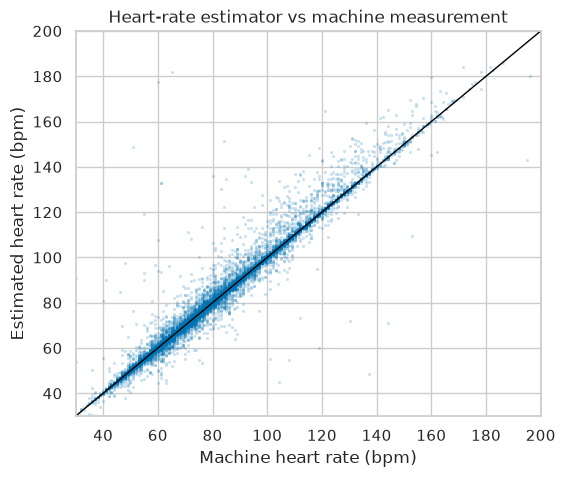

In [13]:
paired = summary[["heart_rate"]].join(intervals["heart_rate"].rename("machine_heart_rate")).dropna()
error = paired["heart_rate"] - paired["machine_heart_rate"]
display(pd.Series({"records compared": len(paired),
                   "median absolute error (bpm)": error.abs().median(),
                   "within 5 bpm": (error.abs() <= 5).mean(),
                   "correlation": paired.corr().iloc[0, 1]}).to_frame("estimated vs machine").round(3))
fig, ax = plt.subplots(figsize=(6, 5))
sample = paired.sample(20000, random_state=0)
sns.scatterplot(sample, x="machine_heart_rate", y="heart_rate", s=4, alpha=0.2, ax=ax, edgecolor=None)
ax.plot([30, 200], [30, 200], color="black", linewidth=1)
ax.set(xlim=(30, 200), ylim=(30, 200), xlabel="Machine heart rate (bpm)",
       ylabel="Estimated heart rate (bpm)", title="Heart-rate estimator vs machine measurement")
plt.show()

,PTB-XL,MIMIC
std,1.525e-01,1.326e-01
peak_abs_mv,1.905e+00,1.635e+00
baseline_fraction,1.990e-02,8.300e-03
high_frequency_fraction,6.600e-03,1.120e-02
powerline_50_fraction,7.000e-04,1.000e-03
powerline_60_fraction,3.000e-04,5.000e-04
heart_rate,7.126e+01,7.463e+01


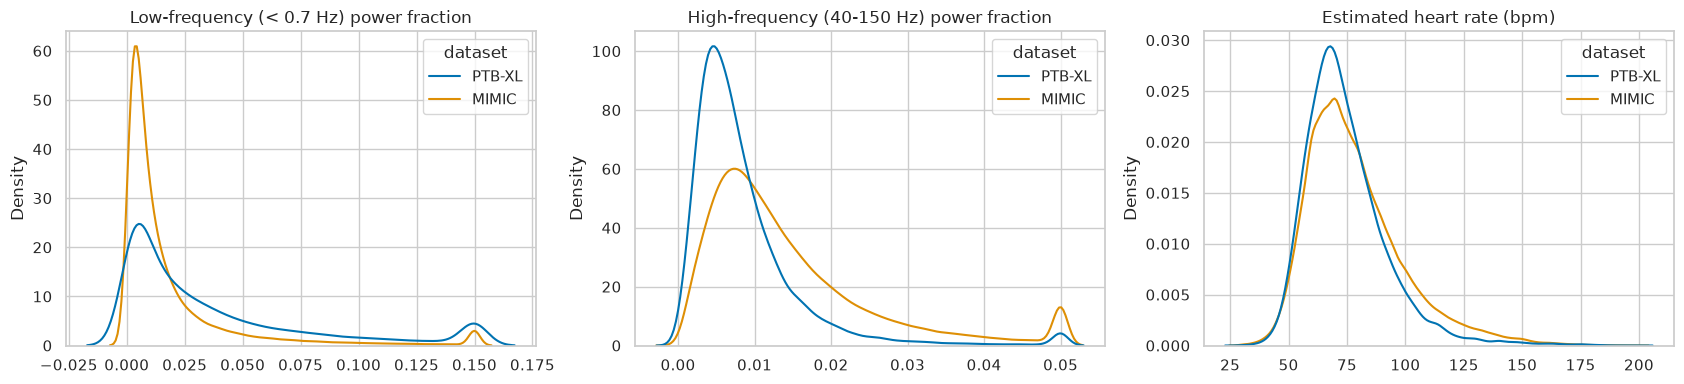

In [14]:
ptbxl = ptbxl_summary(load_metadata())
metrics = ["std", "peak_abs_mv", "baseline_fraction", "high_frequency_fraction",
           "powerline_50_fraction", "powerline_60_fraction", "heart_rate"]
display(pd.DataFrame({"PTB-XL": ptbxl[metrics].median(), "MIMIC": summary[metrics].median()}).round(4))
combined = pd.concat([ptbxl[metrics].assign(dataset="PTB-XL"), summary[metrics].assign(dataset="MIMIC")])
combined["baseline_fraction"] = combined["baseline_fraction"].clip(upper=0.15)
combined["high_frequency_fraction"] = combined["high_frequency_fraction"].clip(upper=0.05)
combined["heart_rate"] = combined["heart_rate"].clip(30, 200)
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
titles = {"baseline_fraction": "Low-frequency (< 0.7 Hz) power fraction",
          "high_frequency_fraction": "High-frequency (40-150 Hz) power fraction",
          "heart_rate": "Estimated heart rate (bpm)"}
for axis, (column, title) in zip(axes, titles.items(), strict=True):
    sns.kdeplot(combined, x=column, hue="dataset", common_norm=False, ax=axis)
    axis.set(title=title, xlabel="")
plt.tight_layout()
plt.show()

**Finding: the heart-rate estimator is reliable, and MIMIC is filtered differently from PTB-XL.**

- Against the machine measurement of about 200,000 records, the estimate has a median error of about
  0.5 bpm, 94% of estimates are within 5 bpm, and the correlation is 0.98.
- Compared with PTB-XL, MIMIC has less than half the low-frequency power (most carts apply a baseline
  filter) and about 1.7x more power above 40 Hz (muscle noise and a wider recording bandwidth), with
  slightly smaller amplitudes and slightly faster heart rates, as expected for hospital and emergency
  patients. Mains interference is negligible in both.

## 7. Conclusions about the dataset

- **Structure.** 800,035 studies from 161,352 patients; 64% of patients have repeat ECGs, often more than
  a year apart. Dates are shifted for privacy. The waveform release has no demographics.
- **Missing and wrong values.** The measurement file has no NaNs but encodes "not measured" as 29999 (up to
  29% of P-wave fields), plus a few impossible values (zero RR intervals, onsets after ends). Clean them
  before use. On the main cart system, QTc is truncated at about 500 ms.
- **Machine reports.** Only 19% of studies are called normal, and 10% mention atrial fibrillation. The
  report findings agree with the intervals that define them, so the reports are coherent proxy labels,
  though not cardiologist diagnoses.
- **Signals.** Complete apart from short NaN gaps in 1.3% of records and 488 dead leads. Leads are stored
  in a non-standard order and must be reordered by name.
- **Acquisition.** One cart (13% of records) forms its own sub-population: no baseline filter, inexact
  limb leads and no interpretation. Overall, MIMIC is filtered and noisier at high frequency than PTB-XL.

The next notebook describes the four PhysioNet Challenge sources.